# STEP 6 — Conditional Transfer Probe (thresholded, honest) + semantic sensitivity

Measures how well a model trained on one set generalizes to ANOTHER set. Two types:
**(a) intra-sector** (Cell2Cell↔Iranian, both directions) and **(b) cross-sector** (telco↔bank,
both directions). Sets are not merged; transfer = "fit on source, predict on target". The scaler
is fit on the source only (no leakage). Model: RAW LightGBM. Predefined threshold
(INCLUDED/PARTIAL/WEAK) — not bent to the result.

**Addendum (sensitivity):** importance-based proxy selection may map semantically different columns
(usage=MonthlyMinutes vs Status). Therefore, for the intra-telecom pair we fix the proxies
**manually by semantics** and rerun the transfer, comparing the two variants.
The heavy logic lives in `src/transfer.py`.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd


def _bul_kok():
    for c in [Path.cwd(), *Path.cwd().parents]:
        if (c / "config.yaml").exists():
            return c
    raise RuntimeError("config.yaml not found")


KOK = _bul_kok()
if str(KOK) not in sys.path:
    sys.path.insert(0, str(KOK))

warnings.filterwarnings("ignore")
from src import config as cfg
from src import plotstyle as ps
from src import strings as S
from src import transfer as tr

np.random.seed(cfg.SEED)
ps.uygula()
cfg.klasorleri_hazirla()
pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)

CIKTI = []


def yaz(s=""):
    print(s)
    CIKTI.append(str(s))

## 1. Data loading

In [2]:
veriler = {k: pd.read_csv(cfg.PROCESSED / f"{k}_clean.csv") for k in cfg.DATASETS}
for k, d in veriler.items():
    yaz(f"{k:11s} {d.shape}")

telco       (7043, 20)
cell2cell   (51047, 57)
ecommerce   (3941, 11)
iranian     (3150, 14)
bank        (10000, 11)


## 2. Importance-based transfer (4 scenarios)

In [3]:
yaz(S.MSG["bolum"].format(ad="TRANSFER PROBE (importance-based)"))
onem = []
for anahtar, ad, ks, ht, tip in tr.SENARYOLAR:
    r = tr.calistir_senaryo(anahtar, ad, ks, ht, tip, veriler, cfg.SEED)
    onem.append(r)
    yaz(S.MSG6["senaryo"].format(ad=r["ad"], yon=r["tip"], k=len(r["ortak"]),
        tr=r["transfer"], ref=r["ref"], tv=r["trivial"], oran=r["oran"],
        karar=S.TRANSFER_KARAR[r["karar"]]))

===== TRANSFER PROBE (importance-based) =====


Cell2Cell -> Iranian (intra-sector): shared concepts=5 | transfer PR-AUC=0.106 | ref=0.845 | trivial=0.157 | ratio=0.13 -> WEAK


Iranian -> Cell2Cell (intra-sector): shared concepts=5 | transfer PR-AUC=0.278 | ref=0.404 | trivial=0.288 | ratio=0.69 -> WEAK


telco -> bank (cross-sector): shared concepts=3 | transfer PR-AUC=0.237 | ref=0.450 | trivial=0.204 | ratio=0.53 -> PARTIAL


bank -> telco (cross-sector): shared concepts=3 | transfer PR-AUC=0.207 | ref=0.622 | trivial=0.265 | ratio=0.33 -> WEAK


## 3. Semantic-mapped transfer (intra-telecom A1/A2)
Proxies are fixed manually by the same operational concept, NOT by importance:
MonthlyMinutes↔Seconds of Use, PeakCallsInOut↔Frequency of use,
CustomerCareCalls↔Complains, MonthsInService↔Subscription Length, MonthlyRevenue↔Customer Value.

In [4]:
yaz(S.MSG["bolum"].format(ad="TRANSFER PROBE (semantic mapping)"))
semantik = []
for anahtar, ad, ks, ht, tip in tr.SENARYOLAR:
    if tip != "intra-sector":
        continue
    r = tr.calistir_semantik(anahtar, ad, ks, ht, veriler, cfg.SEED)
    semantik.append(r)
    yaz(S.MSG6["semantik"].format(ad=r["ad"], k=len(r["ortak"]), tr=r["transfer"],
        ref=r["ref"], tv=r["trivial"], oran=r["oran"], karar=S.TRANSFER_KARAR[r["karar"]]))
    if r["atlanan"]:
        yaz(S.MSG6["atlanan"].format(liste=r["atlanan"]))

===== TRANSFER PROBE (semantic mapping) =====


Cell2Cell -> Iranian [semantic]: concepts=5 | transfer PR-AUC=0.272 | ref=0.870 | trivial=0.157 | ratio=0.31 -> PARTIAL


Iranian -> Cell2Cell [semantic]: concepts=5 | transfer PR-AUC=0.270 | ref=0.395 | trivial=0.288 | ratio=0.68 -> WEAK


## 4. Tables
`transfer_results.csv` (importance + semantic, with the esleme_tipi column) and the mapping tables.

In [5]:
sonuc_df = tr.tablo_sonuc(onem + semantik)
tr.tablo_feature_map(onem)
tr.tablo_feature_map_semantic()
yaz(S.MSG["bolum"].format(ad="TRANSFER RESULTS (importance + semantic)"))
yaz(sonuc_df.to_string(index=False))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "transfer_results.csv"))
yaz(S.MSG["kayit"].format(yol=cfg.TABLES / "transfer_feature_map_semantic.csv"))

===== TRANSFER RESULTS (importance + semantic) =====
Scenario            Direction     Mapping type  Shared concept count  Transfer PR-AUC  In-domain ref PR-AUC  Full-feature ref PR-AUC  Trivial PR-AUC  Retention ratio  Recall  Precision     F1 Decision
      A1 Cell2Cell -> Iranian importance-based                     5           0.1060                0.8449                   0.9576          0.1571            0.125  0.3939     0.0880 0.1438     WEAK
      A2 Iranian -> Cell2Cell importance-based                     5           0.2777                0.4045                   0.4663          0.2882            0.687  0.8210     0.2827 0.4206     WEAK
      B1        telco -> bank importance-based                     3           0.2373                0.4503                   0.7065          0.2037            0.527  0.7545     0.2408 0.3651  PARTIAL
      B2        bank -> telco importance-based                     3           0.2075                0.6219                   0.6635          0

## 5. Figures

===== FIGURES =====


Saved: /Users/emrahfidan/Desktop/makale-2/outputs/figures/_transfer/transfer_prauc_comparison.png
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/figures/_transfer/transfer_retention_ratio.png
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/figures/_transfer/transfer_semantic_vs_importance.png


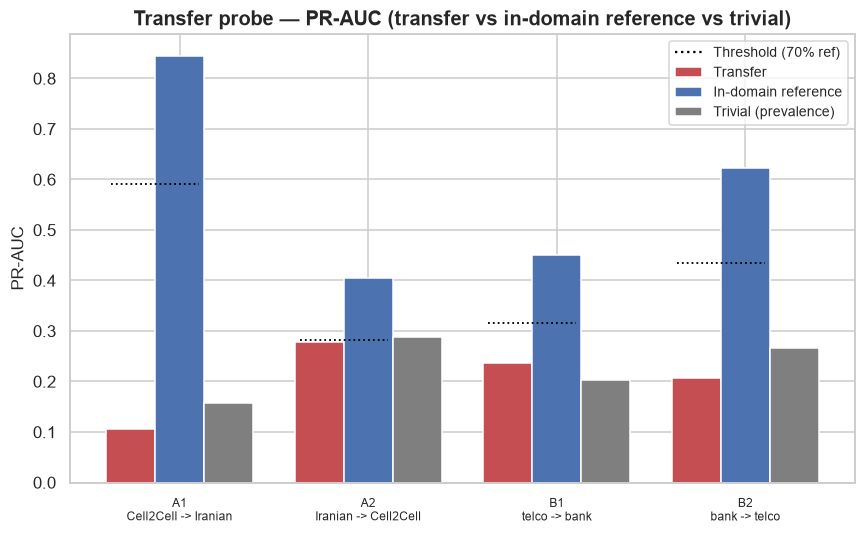

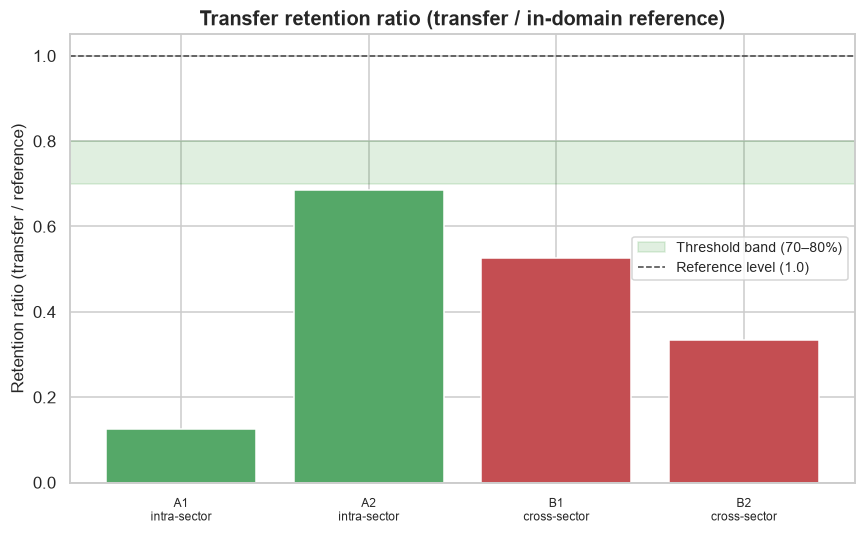

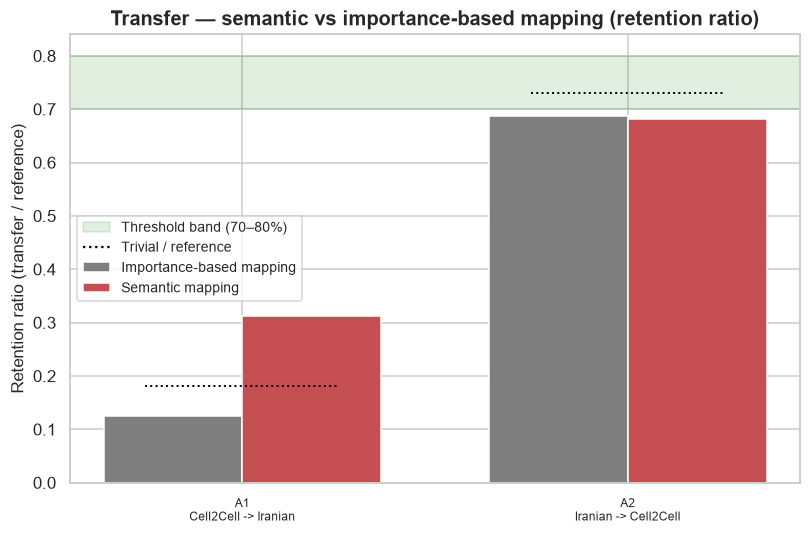

In [6]:
yaz(S.MSG["bolum"].format(ad="FIGURES"))
y1 = tr.figur_prauc(onem)
y2 = tr.figur_retention(onem)
y3 = tr.figur_semantic_vs_importance(onem, semantik)
for y in (y1, y2, y3):
    yaz(S.MSG["kayit"].format(yol=y))

## 6. Summary — did semantic mapping rescue the transfer? (decision left to the user)

In [7]:
yaz(S.MSG["bolum"].format(ad="SUMMARY — semantic vs importance-based"))
onem_map = {r["anahtar"]: r for r in onem}
kurtaran = []
for r in semantik:
    o = onem_map[r["anahtar"]]
    yaz(f"  {r['anahtar']} {r['ad']:22s}: importance ratio={o['oran']:.2f} ({S.TRANSFER_KARAR[o['karar']]}) "
        f"-> semantic ratio={r['oran']:.2f} ({S.TRANSFER_KARAR[r['karar']]})  "
        f"[transfer PR-AUC {o['transfer']:.3f} -> {r['transfer']:.3f}]")
    if r["karar"] == "dahil" or r["oran"] >= o["oran"] + 0.15:
        kurtaran.append(r["anahtar"])

dahil_var = any(r["karar"] == "dahil" for r in semantik)
yaz("")
if not dahil_var:
    yaz("RESULT: Even WITH semantic mapping, no scenario reaches the threshold (no INCLUDED). "
        "The finding is reinforced: weak transfer is not a matching artifact — the drivers "
        "genuinely do not carry across sets/sectors (this strengthens RQ2).")
else:
    yaz(f"RESULT: Semantic mapping recovered the transfer ({kurtaran}); the earlier weakness "
        "was partly an importance-based mapping artifact — a new nuance.")
yaz("")
yaz(S.MSG6["bitti"])

_log = cfg.LOGS / "adim6_ozet.log"
mevcut = _log.read_text(encoding="utf-8") if _log.exists() else ""
_log.write_text(mevcut + "\n\n# ==== SEMANTIC ADDENDUM ====\n" + "\n".join(CIKTI) + "\n", encoding="utf-8")
print(S.MSG["kayit"].format(yol=_log))

===== SUMMARY — semantic vs importance-based =====
  A1 Cell2Cell -> Iranian  : importance ratio=0.13 (WEAK) -> semantic ratio=0.31 (PARTIAL)  [transfer PR-AUC 0.106 -> 0.272]
  A2 Iranian -> Cell2Cell  : importance ratio=0.69 (WEAK) -> semantic ratio=0.68 (WEAK)  [transfer PR-AUC 0.278 -> 0.270]

RESULT: Even WITH semantic mapping, no scenario reaches the threshold (no INCLUDED). The finding is reinforced: weak transfer is not a matching artifact — the drivers genuinely do not carry across sets/sectors (this strengthens RQ2).

STEP 6 (transfer) complete. Interpretation left to the user. No robustness/write-up (Step 7) performed.
Saved: /Users/emrahfidan/Desktop/makale-2/outputs/logs/adim6_ozet.log
